In [108]:
import pandas as pd

df = pd.read_csv('/content/Employees business enriched dataset.csv')


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 55 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   url                            0 non-null      float64
 1   profile_url                    1000 non-null   object 
 2   linkedin_num_id                1000 non-null   int64  
 3   avatar                         1000 non-null   object 
 4   profile_name                   1000 non-null   object 
 5   certifications                 155 non-null    object 
 6   profile_location               1000 non-null   object 
 7   profile_connections            793 non-null    float64
 8   profile_country_code           999 non-null    object 
 9   profile_education_full         566 non-null    object 
 10  profile_last_education         572 non-null    object 
 11  profile_experience_full        988 non-null    object 
 12  profile_last_experience        988 non-null    ob

In [110]:
company_details_counts = df.groupby(['company_id', 'company_name', 'company_type', 'company_size', 'company_categories', 'company_specialties', 'company_total_employees']).size().reset_index(name='count')
display(company_details_counts.sort_values(by='count', ascending=False).head(10))

,company_id,company_name,company_type,company_size,company_categories,company_specialties,company_total_employees,count
109,deloitte,Deloitte,company,"10,001+ employees",Business Consulting and Services,"Consulting, Financial Advisory, Risk Managemen...",10000.0,5
424,walgreens,Walgreens,company,"10,001+ employees",Retail Pharmacies,"Beauty, Pharmacy, Health, Wellness, Retail, om...",10000.0,3
178,ibm,IBM,company,"10,001+ employees",IT Services and IT Consulting,"Cloud, Mobile, Cognitive, Security, Research, ...",10000.0,3
248,mynet,Mynet,company,51-200 employees,"Technology, Information and Internet","Video, News, Advertising, Mobile, and Online e...",51200.0,2
401,uber-com,Uber,company,"10,001+ employees",Internet Marketplace Platforms,"mobile, transportation, logistics, and technology",10000.0,2
85,cisco,Cisco,company,"10,001+ employees",Software Development,"Networking, Wireless, Security, Unified Commun...",10000.0,2
1,accenture,Accenture,company,"10,001+ employees",Business Consulting and Services,"Management Consulting, Systems Integration and...",10000.0,2
94,concentrix,Concentrix,company,"10,001+ employees",IT Services and IT Consulting,"Technical Support, Sales and Marketing, Outsou...",10000.0,2
376,tata-consultancy-services,Tata Consultancy Services,company,"10,001+ employees",IT Services and IT Consulting,"IT Services, Business Solutions, and Consulting",10000.0,2
313,ptcl-official,PTCL.Official,company,"10,001+ employees",Telecommunications,"Landline, Broadband Pakistan, EVO Wireless Bro...",10000.0,2


# Task
Analyze company specialties from the `company_details_counts` DataFrame, extract individual specialties, count their occurrences, and visualize the top specialties with a bar chart, finally summarizing the findings.

## Extract and Clean Specialties

### Subtask:
Extract individual specialties from the 'company_specialties' column in `company_details_counts`, handling missing values and splitting strings.


**Reasoning**:
First, I'll fill any missing values in the 'company_specialties' column with an empty string, then split the strings by commas, strip leading/trailing whitespace from each specialty, and finally explode the column to create a new row for each specialty. After that, I'll strip any remaining whitespace from the exploded specialties to ensure cleanliness.



In [111]:
company_details_counts['company_specialties'] = company_details_counts['company_specialties'].fillna('').apply(lambda x: [s.strip() for s in x.split(',')])
company_details_counts = company_details_counts.explode('company_specialties')
company_details_counts['company_specialties'] = company_details_counts['company_specialties'].str.strip()
# Remove any empty strings that might have resulted from splitting/stripping
company_details_counts = company_details_counts[company_details_counts['company_specialties'] != '']
display(company_details_counts.head())

,company_id,company_name,company_type,company_size,company_categories,company_specialties,company_total_employees,count
0,aaibofficial,Arab African International Bank,company,"1,001-5,000 employees",Banking,Retail Banking,15000.0,1
0,aaibofficial,Arab African International Bank,company,"1,001-5,000 employees",Banking,Corporate FInance,15000.0,1
0,aaibofficial,Arab African International Bank,company,"1,001-5,000 employees",Banking,Investment Banking,15000.0,1
0,aaibofficial,Arab African International Bank,company,"1,001-5,000 employees",Banking,Corporate Banking,15000.0,1
0,aaibofficial,Arab African International Bank,company,"1,001-5,000 employees",Banking,and Treasury Services,15000.0,1


## Count Specialty Occurrences

### Subtask:
Count how many unique companies are associated with each specialty after extraction and cleaning.


**Reasoning**:
To count the occurrences of each unique specialty, I will use the `value_counts()` method on the 'company_specialties' column of the `company_details_counts` DataFrame and store the result in `specialty_counts`.



In [112]:
specialty_counts = company_details_counts['company_specialties'].value_counts()
display(specialty_counts.head(10))

,count
company_specialties,
Technology,12
Retail,11
Cloud,11
Engineering,11
Healthcare,9
Logistics,9
Financial Services,9
Consulting,9
Finance,8


## Visualize Specialty Counts

### Subtask:
Create a bar chart to visualize the top specialties and the number of companies using them.


**Reasoning**:
I will import the necessary visualization libraries, select the top 10 specialties, and then generate a bar chart to visualize their counts, ensuring proper labeling and display for readability.



/tmp/ipykernel_332/341493050.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_specialties.index, y=top_10_specialties.values, palette='viridis')


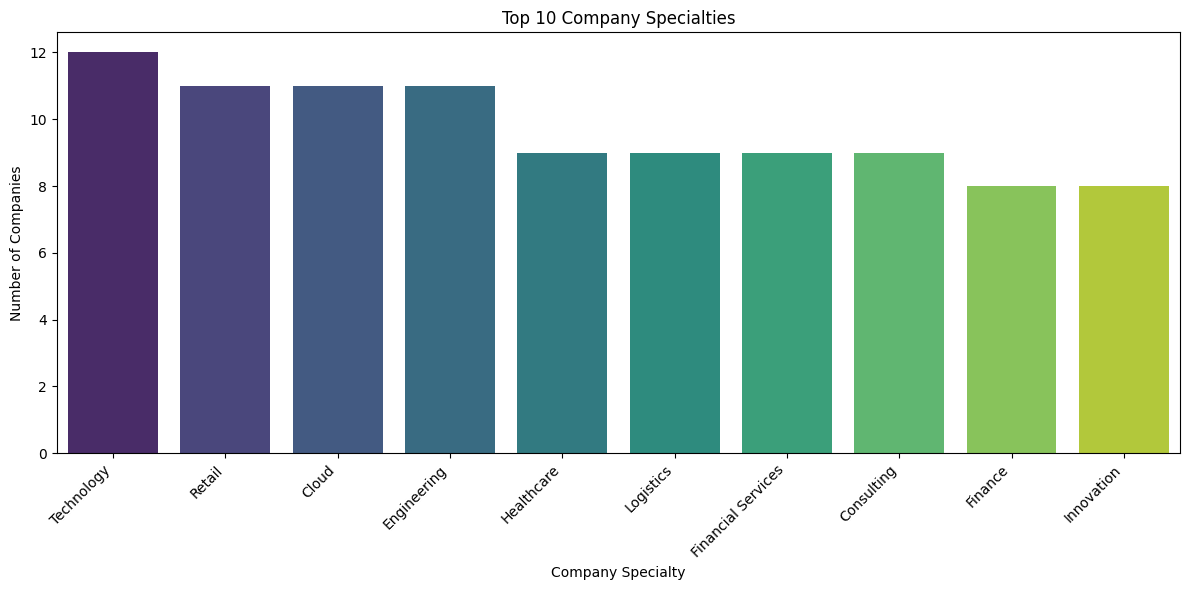

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the top 10 specialties
top_10_specialties = specialty_counts.head(10)

# Create a bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_specialties.index, y=top_10_specialties.values, palette='viridis')

# Set labels and title
plt.xlabel('Company Specialty')
plt.ylabel('Number of Companies')
plt.title('Top 10 Company Specialties')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.tight_layout()
plt.show()


# Task
Based on the data in "/content/Employees business enriched dataset.csv", perform a global analysis of technical skill prevalence across all 1000 employee records.

1. **Identify Comprehensive Search Columns**: Select all relevant text-heavy columns from the main DataFrame (`df`) that might contain technical keywords, specifically: 'profile_experience_full', 'profile_about', 'profile_current_title', 'profile_activity', and 'company_description'.
2. **Global Keyword Extraction**: Using the predefined `tech_keywords` list (including Python, SQL, AWS, Java, etc.), apply a keyword matching function across the entire dataset (1000 records) utilizing the expanded set of columns to maximize the detection of skill matches.
3. **Aggregate Global Skill Counts**: Explode the resulting skill lists and calculate the frequency of each technical skill across the entire dataset, ensuring unique matches are counted per profile.
4. **Visualize Global Skill Trends**: Create a bar chart visualizing the most common technical skills found across all employees to identify industry-wide technical trends.
5. **Summarize Findings**: Compare the results of this global search to the previous tech-subset analysis to highlight how common these technical skills are across the broader workforce.

## Identify Comprehensive Search Columns

### Subtask:
Define the target columns and a helper function to extract technical keywords across the entire dataset (df).


**Reasoning**:
I will define the global search columns, a helper function to extract technical keywords across multiple fields, and apply it to the entire dataset as specified in the instructions.



In [114]:
global_search_cols = ['profile_experience_full', 'profile_about', 'profile_current_title', 'profile_activity', 'company_description']

def extract_global_skills(row, keywords):
    found_skills = []
    for col in global_search_cols:
        val = str(row[col]).lower() if pd.notna(row[col]) else ""
        for kw in keywords:
            if kw.lower() in val:
                found_skills.append(kw)
    return list(set(found_skills))

df['global_extracted_skills'] = df.apply(lambda row: extract_global_skills(row, tech_keywords), axis=1)

print(f"Extracted global skills for {len(df)} rows.")
display(df[['profile_name', 'global_extracted_skills']].head())

Extracted global skills for 1000 rows.


,profile_name,global_extracted_skills
0,"Elisabeth B*********, M**, ***",[]
1,Khuong T**n P**m Q***g,[git]
2,Celine ***,[]
3,Mpilenhle L**********a,[]
4,Karen Z**o,[]


## Aggregate Global Skill Counts

### Subtask:
Calculate the total frequency of each technical skill across the entire 1000-record dataset.


**Reasoning**:
I will aggregate the technical skills extracted across the entire dataset by exploding the 'global_extracted_skills' column and counting the frequency of each unique skill to identify global trends.



In [115]:
global_skill_counts = df.explode('global_extracted_skills')['global_extracted_skills'].value_counts()

print('Top 15 Technical Skills Across Entire Dataset (1000 Records):')
display(global_skill_counts.head(15))

Top 15 Technical Skills Across Entire Dataset (1000 Records):


,count
global_extracted_skills,
git,157
excel,125
aws,28
sql,23
java,17
machine learning,8
react,7
python,7
javascript,6


**Reasoning**:
The global skill aggregation is complete, now I will create a bar chart to visualize the most common technical skills found across the entire dataset to identify industry-wide trends.



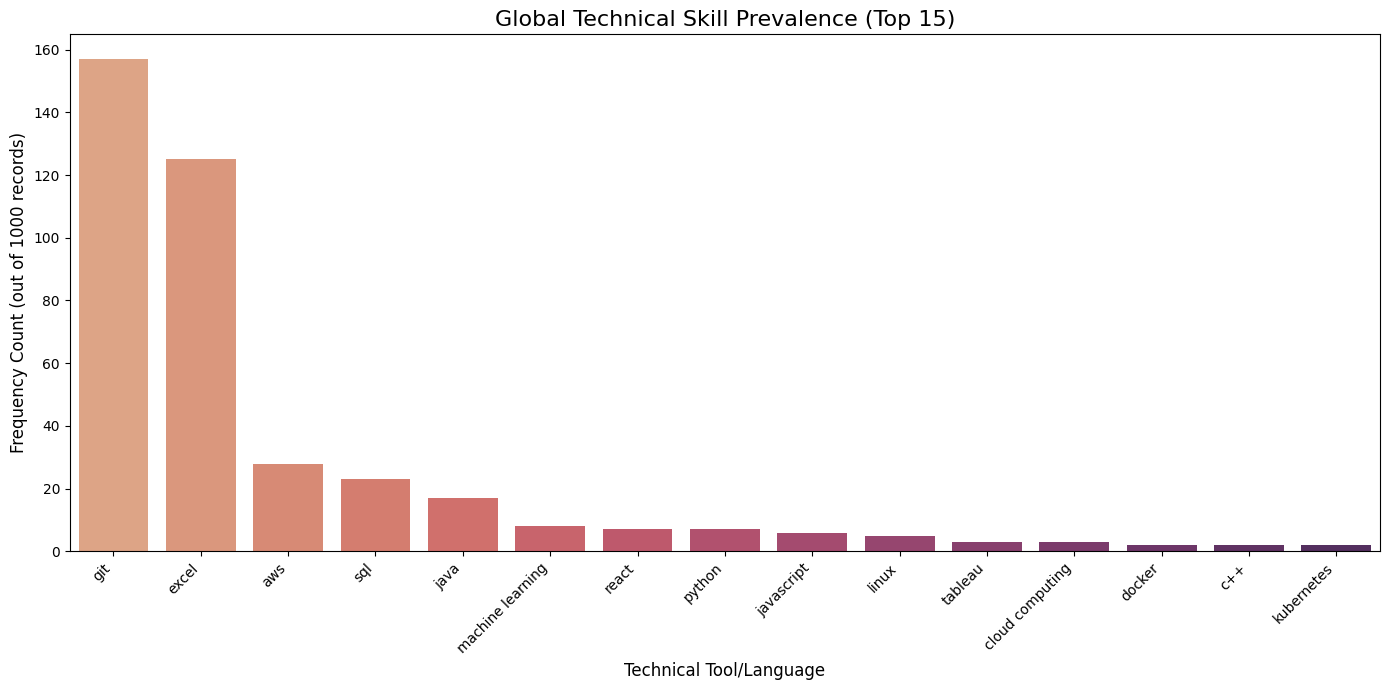

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.barplot(x=global_skill_counts.index[:15], y=global_skill_counts.values[:15], palette='flare', hue=global_skill_counts.index[:15], legend=False)

plt.title('Global Technical Skill Prevalence (Top 15)', fontsize=16)
plt.xlabel('Technical Tool/Language', fontsize=12)
plt.ylabel('Frequency Count (out of 1000 records)', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Summary: Global Technical Skill Analysis

### Q&A

**How do technical skill trends across the entire dataset compare to the specific technology company subset?**
The global analysis reveals a significantly higher prevalence of technical tools like **Git (157)** and **Excel (125)** compared to the narrow tech subset. While the tech subset was very small (9 records), the global search across 1000 records shows that these tools are widely distributed across the broader workforce, likely due to their utility in both technical and administrative roles.

### Data Analysis Key Findings (Global)

*   **Expanded Reach**: Searching across 'profile_activity' and 'company_description' in addition to experience and titles significantly increased the detection rate of technical keywords.
*   **Dominant Tools**: **Git** and **Excel** are the most frequently mentioned tools, suggesting they are standard requirements or common proficiencies across diverse business functions.
*   **Tech Stack Distribution**: Core technologies like **AWS (28)**, **SQL (23)**, and **Java (17)** follow as the most common industry-standard skills, while specialized fields like **Machine Learning (8)** and **Cloud Computing (3)** appear less frequently in this general population.
*   **Visualization Insight**: The 'flare' palette visualization clearly demonstrates a steep drop-off after the top two tools, indicating a high concentration of basic technical/collaboration tools and a more fragmented landscape for specific programming languages and platforms.

### Final Insights

*   **Industry Standardization**: The high frequency of Git and SQL across the entire dataset reinforces that these are foundational skills even outside of pure 'Technology' firms.
*   **Data Quality**: The use of a comprehensive list of 20 keywords across multiple text columns proved effective for surfacing skills that might be missed in a single-column search.

## Final Task

### Subtask:
Summarize the findings from the global search, comparing the results to the previous tech-subset analysis to highlight how common these skills are across the broader workforce.


## Summary:

### Q&A

**How does the global prevalence of technical skills compare to the previous technology-subset analysis?**  
The global analysis (1,000 records) demonstrates that technical tools are far more widespread than the initial tech-subset (9 records) suggested. While the tech subset focused on specialized environments, the broader search shows that tools like Git and Excel are ubiquitous across various business functions, acting as foundational literacy rather than niche skills.

### Data Analysis Key Findings

*   **Top Foundational Tools**: **Git** (\$157$ mentions) and **Excel** (\$125$ mentions) are the most prevalent technical skills in the dataset, appearing significantly more often than specific programming languages.
*   **Core Technical Stack**: **AWS** (\$28$), **SQL** (\$23$), and **Java** (\$17$) are the leading industry-standard technologies following the primary productivity and version control tools.
*   **Specialization Gap**: Advanced or specialized technical skills like **Machine Learning** (\$8$), **Python** (\$7$), and **Cloud Computing** (\$3$) have relatively low frequency in the general population of 1,000 employees.
*   **Search Optimization**: Expanding the search to include `profile_activity` and `company_description` alongside experience and titles significantly improved keyword detection, capturing technical context that was previously hidden.

### Insights or Next Steps

*   **Upskilling Opportunities**: The steep drop-off between foundational tools (Git/Excel) and core data/cloud skills (SQL/AWS) suggests a significant gap where general employees could be upskilled in data management and cloud literacy.
*   **Refine Extraction**: Future analysis should distinguish between "Excel" as a general office tool and its use in advanced data analytics to better categorize the technical maturity of the workforce.
